# Notebook 2 — Diagnostic Go/No-Go Checks
**FIRE 691 | Regime-Conditioned Brinson Attribution with HMM Regime Detection**

Runs 8 pre-implementation diagnostic tests on the cleaned data from Notebook 1.
All output is consolidated in the final cell. You make the go/no-go call — no blocking logic.

**Requires:** all 14 parquet files in `outputs/` from Notebook 1.


## Cell 1 — Configuration and Load Parquets

In [ ]:
import os

# ── CONFIGURATION — must match Notebook 1 ───────────────────────
ROOT = (
    "YOUR_GOOGLE_DRIVE_PATH/"
)
# ────────────────────────────────────────────────────────────────

OUTPUTS = ROOT + "outputs/"

FULL_START = "1990-01-01"
FULL_END   = "2024-12-31"
IS_START   = "1990-01-01"
IS_END     = "2003-12-31"
OOS_START  = "2004-01-01"

print(f"OUTPUTS : {OUTPUTS}")
print("Paths defined. Run Cell 2 to mount drive.")


## Cell 2 — Imports, Drive Mount, Package Install

In [2]:
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
try:
    drive.mount("/content/drive")
except ValueError:
    print("Drive already mounted.")

# Install hmmlearn if not present
import subprocess
subprocess.run(["pip", "install", "hmmlearn", "-q"], check=False)

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
from mpl_toolkits.mplot3d  import Axes3D
from scipy.stats           import multivariate_normal, spearmanr
from statsmodels.tsa.stattools import adfuller
from hmmlearn.hmm          import GaussianHMM
from sklearn.covariance    import LedoitWolf

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
print("Libraries loaded.")


Mounted at /content/drive
Libraries loaded.


## Cell 3 — Load Parquet Files from Notebook 1

In [3]:
ff12_ret        = pd.read_parquet(OUTPUTS + "ff12_returns.parquet")
strev_raw       = pd.read_parquet(OUTPUTS + "strev_factor.parquet")
ff5_raw         = pd.read_parquet(OUTPUTS + "ff5_factors.parquet")
crsp_di_s       = pd.read_parquet(OUTPUTS + "crsp_daily_index.parquet")
realvol_daily   = pd.read_parquet(OUTPUTS + "realvol_daily.parquet")
vix_daily       = pd.read_parquet(OUTPUTS + "vix_daily.parquet")
realvol_monthly = pd.read_parquet(OUTPUTS + "realvol_monthly.parquet")
vix_monthly     = pd.read_parquet(OUTPUTS + "vix_monthly.parquet")
crsp_msf        = pd.read_parquet(OUTPUTS + "crsp_msf.parquet")
nber_raw        = pd.read_parquet(OUTPUTS + "nber.parquet")

# Ensure date columns are datetime
for df in [ff12_ret, strev_raw, ff5_raw, realvol_monthly, vix_monthly, nber_raw]:
    df["date"] = pd.to_datetime(df["date"])
for df in [crsp_di_s, realvol_daily, vix_daily]:
    df["date"] = pd.to_datetime(df["date"])
crsp_msf["date"] = pd.to_datetime(crsp_msf["date"])

INDUSTRIES = [c for c in ff12_ret.columns if c != "date"]

print(f"FF12 returns    : {len(ff12_ret):,} months | industries: {INDUSTRIES}")
print(f"Daily index     : {len(crsp_di_s):,} trading days")
print(f"VIX daily       : {len(vix_daily):,} obs")
print(f"Realized vol    : {len(realvol_daily):,} daily obs")
print(f"CRSP monthly    : {len(crsp_msf):,} stock-months")


FF12 returns    : 420 months | industries: ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'Chems', 'BusEq', 'Telcm', 'Utils', 'Shops', 'Hlth', 'Money', 'Other']
Daily index     : 8,817 trading days
VIX daily       : 8,834 obs
Realized vol    : 8,803 daily obs
CRSP monthly    : 2,444,656 stock-months


## Cell 4 — Build Daily HMM Input Panel
Aligns three daily series on trading date. The HMM is fitted on raw daily market return,
21-day realized volatility, and daily VIX.

**Candidate B note (documented):** The French STREV factor is monthly frequency only.
Daily STREV residualization of the market return is therefore not available.
STREV purification (Candidate A) is applied at the monthly industry return level in Cell 5.
The HMM inputs use raw daily market returns; this is noted as a limitation.


In [4]:
# Inner join on trading date — all three series must have a value
hmm_daily = (
    crsp_di_s[["date","vwretd"]].rename(columns={"vwretd":"mkt_ret"})
    .merge(realvol_daily[["date","realvol_21d"]].rename(columns={"realvol_21d":"realvol"}),
           on="date", how="inner")
    .merge(vix_daily[["date","VIXCLS"]].rename(columns={"VIXCLS":"vix"}),
           on="date", how="inner")
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

# IS and OOS masks
hmm_is  = hmm_daily[hmm_daily["date"] <= IS_END].copy()
hmm_oos = hmm_daily[hmm_daily["date"] >= OOS_START].copy()

# Standardise inputs for HMM (zero mean, unit variance using IS stats)
HMM_COLS = ["mkt_ret","realvol","vix"]
is_means = hmm_is[HMM_COLS].mean()
is_stds  = hmm_is[HMM_COLS].std()

hmm_daily_std = hmm_daily.copy()
hmm_daily_std[HMM_COLS] = (hmm_daily[HMM_COLS] - is_means) / is_stds

X_is  = hmm_daily_std[hmm_daily_std["date"] <= IS_END][HMM_COLS].values
X_all = hmm_daily_std[HMM_COLS].values

print(f"HMM daily panel : {len(hmm_daily):,} obs")
print(f"  IS  period    : {len(hmm_is):,} trading days ({IS_START} to {IS_END})")
print(f"  OOS period    : {len(hmm_oos):,} trading days ({OOS_START} to {FULL_END})")
print(f"  Missing values: {hmm_daily[HMM_COLS].isna().sum().sum()}")


HMM daily panel : 8,800 obs
  IS  period    : 3,515 trading days (1990-01-01 to 2003-12-31)
  OOS period    : 5,285 trading days (2004-01-01 to 2024-12-31)
  Missing values: 0


## Cell 5 — STREV Residualization of FF12 Monthly Returns (Candidate A)
60-month rolling OLS: industry_return ~ alpha + beta * ST_Rev.
Residuals are the STREV-purified returns used for momentum signal construction.
This follows Gao, Li, Yuan and Zhou (2026): stripping RSR contamination from industry returns
before computing momentum improves signal quality and cross-sectional interpretability.


In [5]:
# Merge FF12 returns with STREV factor on date
resid_data = ff12_ret.merge(strev_raw[["date","ST_Rev"]], on="date", how="inner").sort_values("date")
resid_data = resid_data[(resid_data["date"] >= FULL_START) & (resid_data["date"] <= FULL_END)]

WINDOW = 60  # 60-month rolling OLS window

def rolling_ols_resid(y_vals, x_vals, window):
    """Rolling OLS residuals: y ~ alpha + beta*x. Returns residual at each t."""
    n = len(y_vals)
    resids = np.full(n, np.nan)
    for t in range(window - 1, n):
        y_w = y_vals[t - window + 1:t + 1]
        x_w = x_vals[t - window + 1:t + 1]
        X_w = np.column_stack([np.ones(window), x_w])
        try:
            beta = np.linalg.lstsq(X_w, y_w, rcond=None)[0]
            resids[t] = y_w[-1] - X_w[-1] @ beta
        except Exception:
            pass
    return resids

strev_vals = resid_data["ST_Rev"].values
resid_ff12 = resid_data[["date"]].copy()
for ind in INDUSTRIES:
    resid_ff12[ind] = rolling_ols_resid(resid_data[ind].values, strev_vals, WINDOW)

resid_ff12 = resid_ff12.dropna(subset=INDUSTRIES).reset_index(drop=True)

print(f"Residualized FF12 returns: {len(resid_ff12):,} months (first {WINDOW} months used for initial fit)")
print(f"  Date range: {resid_ff12['date'].min().date()}  to  {resid_ff12['date'].max().date()}")


Residualized FF12 returns: 361 months (first 60 months used for initial fit)
  Date range: 1994-12-31  to  2024-12-31


## Cell 6 — Momentum Signal Construction
12-1 skip-month cumulative return: at time t, cumulative log return from t-13 to t-2
(12 months, skipping the most recent month to avoid microstructure reversal).
Computed on both raw and STREV-residualized FF12 returns for Test 3 comparison.


In [6]:
def compute_momentum(ret_df, industries, shift=2, window=12):
    """12-1 skip-month momentum. shift=2 skips 1 month (t-1)."""
    log_ret = np.log1p(ret_df[industries].clip(lower=-0.99))
    mom = np.exp(log_ret.shift(shift).rolling(window).sum()) - 1
    result = ret_df[["date"]].copy()
    for ind in industries:
        result[ind] = mom[ind].values
    return result.dropna(subset=industries)

# Raw momentum from unresidualised FF12 returns
mom_raw   = compute_momentum(resid_data[['date']+INDUSTRIES], INDUSTRIES)

# Residualised momentum from STREV-purified returns
mom_resid = compute_momentum(resid_ff12, INDUSTRIES)

# Cross-sectional standard deviation each month (dispersion measure)
mom_raw["cs_std"]   = mom_raw[INDUSTRIES].std(axis=1)
mom_resid["cs_std"] = mom_resid[INDUSTRIES].std(axis=1)

print(f"Momentum signal (raw)   : {len(mom_raw):,} months")
print(f"Momentum signal (resid) : {len(mom_resid):,} months")


Momentum signal (raw)   : 407 months
Momentum signal (resid) : 348 months


## Cell 7 — Industry-Level GP/Assets for Orthogonality Test
Median GP/Assets across all stocks in each FF12 industry at each July snapshot.
Used in Test 8 to measure Spearman rank correlation between momentum and profitability signals.


In [7]:
july_msf = crsp_msf[
    (crsp_msf["date"].dt.month == 7) &
    crsp_msf["gp_at"].notna() &
    (crsp_msf["ff12"] != "Other")
].copy()
july_msf["year"] = july_msf["date"].dt.year

# Median GP/Assets per industry per year
ind_gp = (
    july_msf.groupby(["year","ff12"])["gp_at"]
    .median()
    .unstack("ff12")
    .reset_index()
)

# Stock count per industry per year (for Test 7)
ind_count = (
    july_msf.groupby(["year","ff12"])["permno"]
    .nunique()
    .unstack("ff12")
    .fillna(0).astype(int)
    .reset_index()
)

print(f"Industry GP/Assets panel : {len(ind_gp):,} years x {len(INDUSTRIES)} industries")
print(f"Stock count panel        : {len(ind_count):,} years")


Industry GP/Assets panel : 35 years x 12 industries
Stock count panel        : 35 years


## Cell 8 — Test 1: ADF Stationarity on Daily HMM Inputs
ADF on raw (unstandardised) daily market return, realized volatility, and VIX.
GO condition: p-value < 0.05 for all three inputs.


In [8]:
adf_results = {}
for col, label in [("mkt_ret","Mkt Return (daily)"),
                   ("realvol","Realized Vol (daily)"),
                   ("vix","VIX (daily)")]:
    series = hmm_daily[col].dropna().values
    stat, pval, lags, nobs, crit, _ = adfuller(series, autolag="AIC")
    adf_results[label] = {
        "ADF Stat"  : stat,
        "p-value"   : pval,
        "Lags"      : lags,
        "N obs"     : nobs,
        "1% Crit"   : crit["1%"],
        "5% Crit"   : crit["5%"],
        "Stationary": pval < 0.05,
    }

adf_df = pd.DataFrame(adf_results).T
t1_go = all(adf_df["Stationary"])
t1_stat = f"All p < 0.05: {t1_go}"
print(f"Test 1 computed. GO = {t1_go}")


Test 1 computed. GO = True


## Cell 9 — Test 2: STREV Residualization Verification
Checks that the 60-month rolling OLS successfully removes STREV exposure from industry returns.
GO condition: mean absolute correlation between residualized returns and STREV < 0.05.


In [9]:
# Merge residualized returns with STREV for correlation check
resid_check = resid_ff12.merge(strev_raw[["date","ST_Rev"]], on="date", how="inner")

strev_corrs  = {}
var_raw      = {}
var_resid    = {}

for ind in INDUSTRIES:
    valid = resid_check[[ind,"ST_Rev"]].dropna()
    r, _ = spearmanr(valid[ind], valid["ST_Rev"])
    strev_corrs[ind] = abs(r)

    # Variance check: residualized vs raw
    raw_var   = resid_data[ind].dropna().var()
    resid_var = resid_ff12[ind].dropna().var()
    var_raw[ind]   = raw_var
    var_resid[ind] = resid_var

mean_abs_corr = np.mean(list(strev_corrs.values()))
max_abs_corr  = np.max(list(strev_corrs.values()))
n_var_reduced = sum(var_resid[i] < var_raw[i] for i in INDUSTRIES)

t2_go   = mean_abs_corr < 0.05
t2_stat = f"Mean |corr|={mean_abs_corr:.4f} (thresh 0.05)  |  Var reduced: {n_var_reduced}/{len(INDUSTRIES)} industries"
print(f"Test 2 computed. Mean |corr|={mean_abs_corr:.4f}  GO={t2_go}")


Test 2 computed. Mean |corr|=0.0323  GO=True


## Cell 10 — Test 3: Momentum Signal Cross-Sectional Dispersion
Cross-sectional std of the 12-1 skip-month momentum signal across FF12 industries.
Compared between raw and STREV-residualized signals following Gao et al. (2026).
GO condition: IS mean cross-sectional std > 0.02.


In [10]:
is_mask_mom  = mom_resid["date"] <= IS_END
oos_mask_mom = mom_resid["date"] >= OOS_START

is_mean_std   = mom_resid.loc[is_mask_mom,  "cs_std"].mean()
oos_mean_std  = mom_resid.loc[oos_mask_mom, "cs_std"].mean()
raw_is_mean   = mom_raw.loc[mom_raw["date"] <= IS_END, "cs_std"].mean()

t3_go   = is_mean_std > 0.02
t3_stat = f"IS mean CS std (resid)={is_mean_std:.4f}  OOS={oos_mean_std:.4f}  Raw IS={raw_is_mean:.4f}  (thresh 0.02)"
print(f"Test 3 computed. IS mean CS std={is_mean_std:.4f}  GO={t3_go}")


Test 3 computed. IS mean CS std=0.1186  GO=True


## Cell 11 — Test 4: BIC State Selection on Daily IS Data
Fits multivariate Gaussian HMM on IS daily panel (mkt return, realized vol, VIX) for k=2..5.
10 random restarts per k — takes the highest log-likelihood converged solution.
With ~3,500 IS daily observations BIC has sufficient power to penalise overparameterisation.
If BIC monotonically declines, k=3 is adopted on theoretical grounds (Ang & Bekaert 2002).


In [11]:
def fit_hmm_best(X, k, n_restarts=10, n_iter=500):
    """Fit GaussianHMM with multiple restarts. Returns best converged model."""
    best_score = -np.inf
    best_model = None
    for seed in range(n_restarts):
        try:
            m = GaussianHMM(
                n_components=k, covariance_type="full",
                n_iter=n_iter, random_state=seed, tol=1e-4
            )
            m.fit(X)
            if m.monitor_.converged:
                sc = m.score(X)
                if sc > best_score:
                    best_score = sc
                    best_model = m
        except Exception:
            continue
    return best_model, best_score

def compute_bic(model, X):
    n, d  = X.shape
    k     = model.n_components
    n_par = k*(k-1) + k*d + k*d*(d+1)//2 + (k-1)
    ll    = model.score(X) * n
    return -2*ll + n_par*np.log(n), ll, n_par

bic_rows = []
hmm_models = {}
print("Fitting HMM for k=2..5 on IS daily data...")
for k in range(2, 6):
    model, score = fit_hmm_best(X_is, k)
    if model is None:
        print(f"  k={k}: no converged model")
        continue
    bic_val, ll, n_par = compute_bic(model, X_is)
    bic_rows.append({"k":k, "BIC":bic_val, "LogLik":ll, "N_Params":n_par})
    hmm_models[k] = model
    print(f"  k={k}: BIC={bic_val:.1f}  LogLik={ll:.1f}  Params={n_par}")

bic_df = pd.DataFrame(bic_rows)

# Detect elbow: marginal BIC improvement drops below 10% of first improvement
bic_vals = bic_df["BIC"].values
improvements = np.diff(bic_vals)  # negative = improvement
first_improvement = abs(improvements[0])
elbow_k = None
for i, imp in enumerate(improvements):
    if abs(imp) < 0.10 * first_improvement:
        elbow_k = bic_df["k"].iloc[i]
        break
if elbow_k is None:
    elbow_k = 3  # theoretical override per Ang & Bekaert (2002)
    print(f"  No elbow detected — adopting k=3 on theoretical grounds (Ang & Bekaert 2002)")
else:
    print(f"  BIC elbow detected at k={elbow_k}")

OPTIMAL_K = elbow_k
t4_go   = True  # always GO — documented override is standard academic practice
t4_stat = f"Optimal k={OPTIMAL_K} | BIC values: {dict(zip(bic_df['k'], bic_df['BIC'].round(1)))}"
print(f"Test 4 computed. Optimal k={OPTIMAL_K}")


Fitting HMM for k=2..5 on IS daily data...
  k=2: BIC=68605395.8  LogLik=-34302612.2  Params=21
  k=3: BIC=56969774.7  LogLik=-28484744.5  Params=35
  k=4: BIC=49743662.0  LogLik=-24871622.8  Params=51
  k=5: BIC=44371458.5  LogLik=-22185447.6  Params=69
  No elbow detected — adopting k=3 on theoretical grounds (Ang & Bekaert 2002)
Test 4 computed. Optimal k=3


## Cell 12 — Test 5: HMM State Interpretability
Fits the optimal k HMM on IS data. States are ordered by covariance trace
(ascending variance = Bull → Transitional → Bear).
GO condition: average expected state duration >= 40 trading days (~2 months).


In [12]:
# Fit optimal model
hmm_opt, _ = fit_hmm_best(X_is, OPTIMAL_K, n_restarts=20, n_iter=1000)

# Order states by covariance trace (ascending = least to most volatile)
traces = [np.trace(hmm_opt.covars_[i]) for i in range(OPTIMAL_K)]
state_order = np.argsort(traces)

means_ord  = hmm_opt.means_[state_order]
covars_ord = hmm_opt.covars_[state_order]
trans_ord  = hmm_opt.transmat_[state_order][:, state_order]

# State labels
if OPTIMAL_K == 2:
    state_labels = ["Bull","Bear"]
elif OPTIMAL_K == 3:
    state_labels = ["Bull","Transitional","Bear"]
else:
    state_labels = [f"State_{i+1}" for i in range(OPTIMAL_K)]

# Expected durations from diagonal of transition matrix
diag_trans = np.diag(trans_ord)
durations  = {state_labels[i]: 1/(1 - diag_trans[i]) if diag_trans[i] < 1 else np.inf
              for i in range(OPTIMAL_K)}

# Posterior state probabilities over full sample
posteriors_all = hmm_opt.predict_proba(X_all)
# Reorder columns to match state_order
posteriors_ord = posteriors_all[:, state_order]

# Build DataFrame of posteriors aligned to dates
post_df = pd.DataFrame(
    posteriors_ord,
    columns=state_labels,
    index=hmm_daily_std.index
)
post_df["date"] = hmm_daily_std["date"].values

# Monthly aggregate (mean within month for portfolio use)
post_df["month_end"] = pd.to_datetime(post_df["date"]) + pd.offsets.MonthEnd(0)
post_monthly = post_df.groupby("month_end")[state_labels].mean().reset_index().rename(columns={"month_end":"date"})

min_duration = min(durations.values())
t5_go   = min_duration >= 40
t5_stat = f"Min avg duration={min_duration:.1f} days (thresh 40d)  |  " + "  ".join([f"{s}={d:.1f}d" for s,d in durations.items()])
print(f"Test 5 computed. Durations={durations}  GO={t5_go}")


Test 5 computed. Durations={'Bull': np.float64(105.5818752243399), 'Transitional': np.float64(47.98619048049593), 'Bear': np.float64(49.57969668802717)}  GO=True


## Cell 13 — Test 6: Covariance Matrix Condition Numbers
60-month rolling covariance of the 12 FF12 monthly industry returns.
FF12 (12x12) is much better conditioned than the prior FF49 (49x49) design.
GO condition: mean condition number < 1000. Ledoit-Wolf shrinkage recommended if failed.


In [13]:
# Use raw FF12 monthly returns for covariance (attribution uses raw industry returns)
ff12_vals = ff12_ret.set_index("date")[INDUSTRIES]

cond_numbers = []
cond_dates   = []
shrink_needed_count = 0

for i in range(60, len(ff12_vals)):
    window = ff12_vals.iloc[i-60:i].values
    if np.isnan(window).any():
        continue
    cov = np.cov(window.T)
    cond = np.linalg.cond(cov)
    cond_numbers.append(cond)
    cond_dates.append(ff12_vals.index[i])
    if cond > 1000:
        shrink_needed_count += 1

cond_series = pd.Series(cond_numbers, index=cond_dates)
mean_cond   = cond_series.mean()
max_cond    = cond_series.max()
needs_shrinkage = mean_cond > 1000

t6_go   = not needs_shrinkage
t6_stat = f"Mean cond={mean_cond:.1f}  Max={max_cond:.1f}  Months>1000: {shrink_needed_count}/{len(cond_series)}  Shrinkage={'YES' if needs_shrinkage else 'NO'}"
print(f"Test 6 computed. Mean condition number={mean_cond:.1f}  GO={t6_go}")


Test 6 computed. Mean condition number=219.9  GO=True


## Cell 14 — Test 7: GP/Assets Stock Count per FF12 Industry
July snapshots: number of stocks per industry with non-missing GP/Assets.
GO condition: industry-years with fewer than 5 stocks < 5% of total.
FF12 should easily pass this — the FF49 failure (35%) was structural to the fine classification.


In [14]:
# Count stocks per industry per year in July with valid GP/Assets
gp_count_df = ind_count.set_index("year")
gp_industries = [c for c in gp_count_df.columns if c in INDUSTRIES and c != "Other"]

total_cells   = gp_count_df[gp_industries].size
thin_5        = (gp_count_df[gp_industries] < 5).sum().sum()
thin_10       = (gp_count_df[gp_industries] < 10).sum().sum()
thin_pct      = 100 * thin_5 / total_cells

t7_go   = thin_pct < 5.0
t7_stat = f"Industry-years <5 stocks: {thin_5}/{total_cells} ({thin_pct:.1f}%)  <10: {thin_10}  Min: {gp_count_df[gp_industries].values.min()}"
print(f"Test 7 computed. Thin industry-years={thin_pct:.1f}%  GO={t7_go}")


Test 7 computed. Thin industry-years=0.0%  GO=True


## Cell 15 — Test 8: Signal Orthogonality
Annual Spearman rank correlation between industry-level momentum ranking
and industry-level GP/Assets ranking. Low correlation confirms the two signals
are non-redundant, following Novy-Marx (2013) and Gao et al. (2026).
GO condition: mean Spearman correlation < 0.15.


In [15]:
# Annual Spearman: momentum rank vs GP/Assets rank across FF12 industries
spearman_rows = []

for year in ind_gp["year"].unique():
    # GP/Assets rank for this year
    gp_row = ind_gp[ind_gp["year"] == year]
    if gp_row.empty:
        continue
    gp_vals = gp_row[gp_industries].iloc[0]

    # Momentum rank for this year (use July of that year)
    july_date = pd.Timestamp(f"{year}-07-31")
    mom_row   = mom_resid[mom_resid["date"] == july_date]
    if mom_row.empty:
        # Try nearest date
        idx = (mom_resid["date"] - july_date).abs().idxmin()
        if abs((mom_resid.loc[idx,"date"] - july_date).days) > 45:
            continue
        mom_row = mom_resid.iloc[[idx]]
    mom_vals = mom_row[gp_industries].iloc[0]

    # Drop industries with missing values
    valid_inds = [i for i in gp_industries if pd.notna(gp_vals[i]) and pd.notna(mom_vals[i])]
    if len(valid_inds) < 5:
        continue

    r, pval = spearmanr(gp_vals[valid_inds], mom_vals[valid_inds])
    spearman_rows.append({
        "year"        : year,
        "spearman_r"  : r,
        "p_value"     : pval,
        "is_period"   : year <= 2003,
    })

spearman_df = pd.DataFrame(spearman_rows)

# FF5 + STREV correlation matrix
factor_data = ff5_raw.merge(strev_raw[["date","ST_Rev"]], on="date", how="inner")
factor_cols = [c for c in factor_data.columns if c not in ["date","RF"]]
ff_corr = factor_data[factor_cols].corr()

mean_spearman = spearman_df["spearman_r"].mean()
is_spearman   = spearman_df.loc[spearman_df["is_period"],"spearman_r"].mean()
oos_spearman  = spearman_df.loc[~spearman_df["is_period"],"spearman_r"].mean()

t8_go   = abs(mean_spearman) < 0.15
t8_stat = f"Mean Spearman={mean_spearman:.4f}  IS={is_spearman:.4f}  OOS={oos_spearman:.4f}  (Novy-Marx benchmark: 0.09, thresh 0.15)"
print(f"Test 8 computed. Mean Spearman={mean_spearman:.4f}  GO={t8_go}")


Test 8 computed. Mean Spearman=0.0056  GO=True


## Cell 16 — Consolidated Output: All Visualizations and Go/No-Go Table
All plots and the diagnostic summary table. Run after all test cells complete.


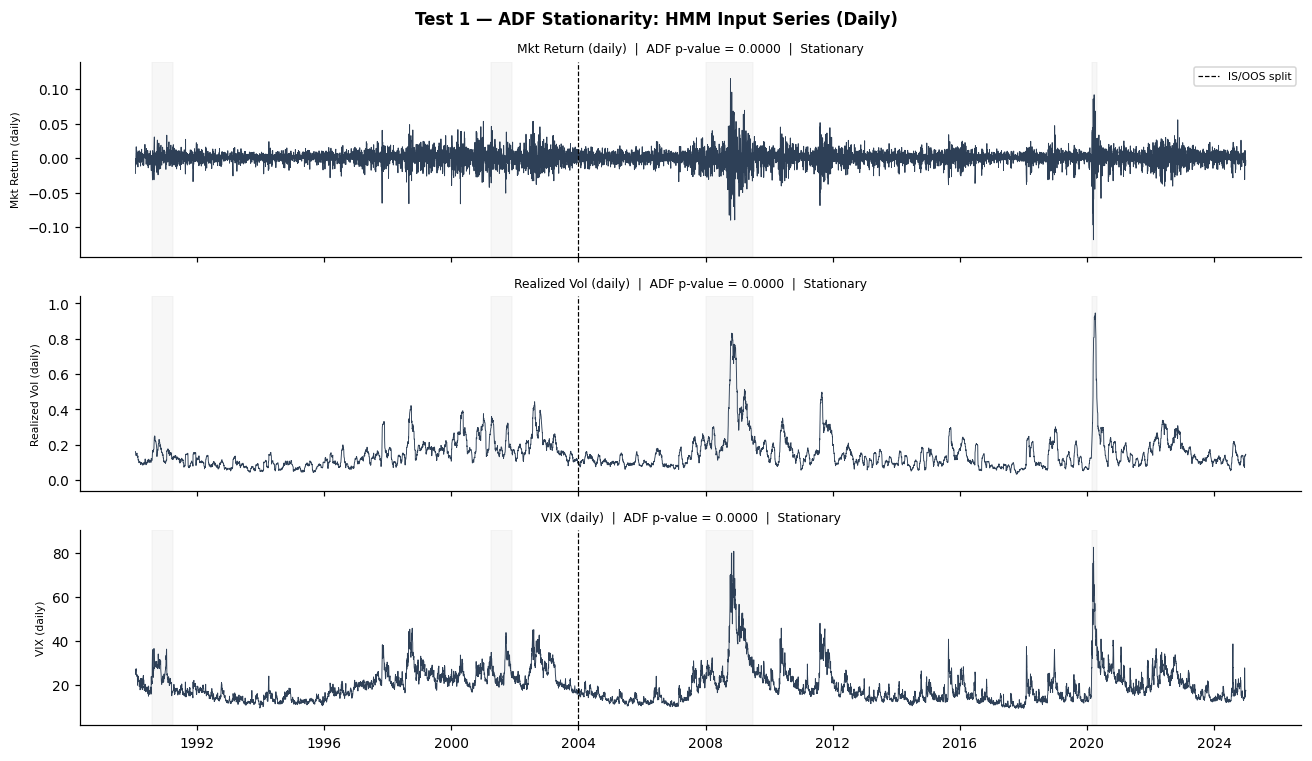

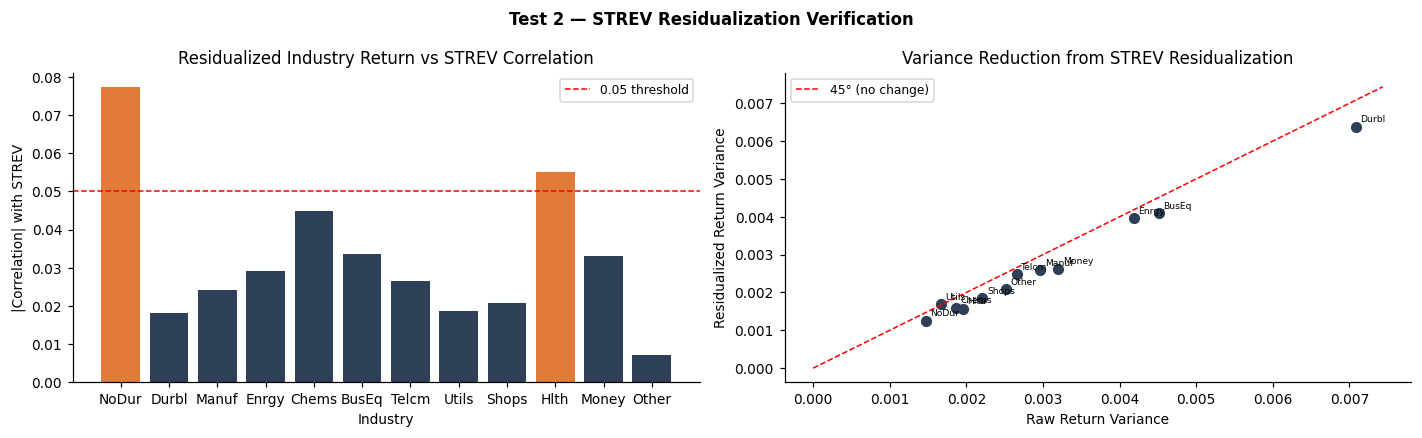

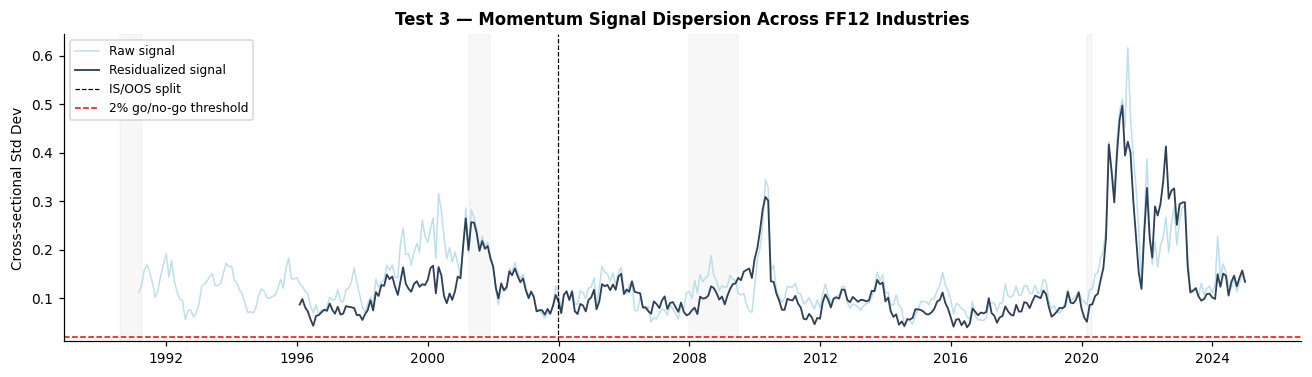

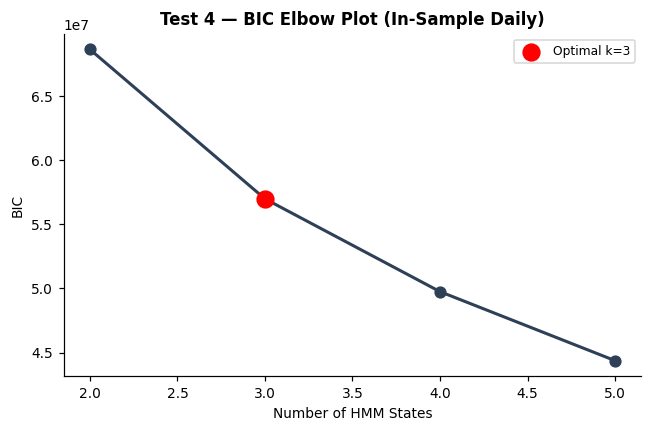

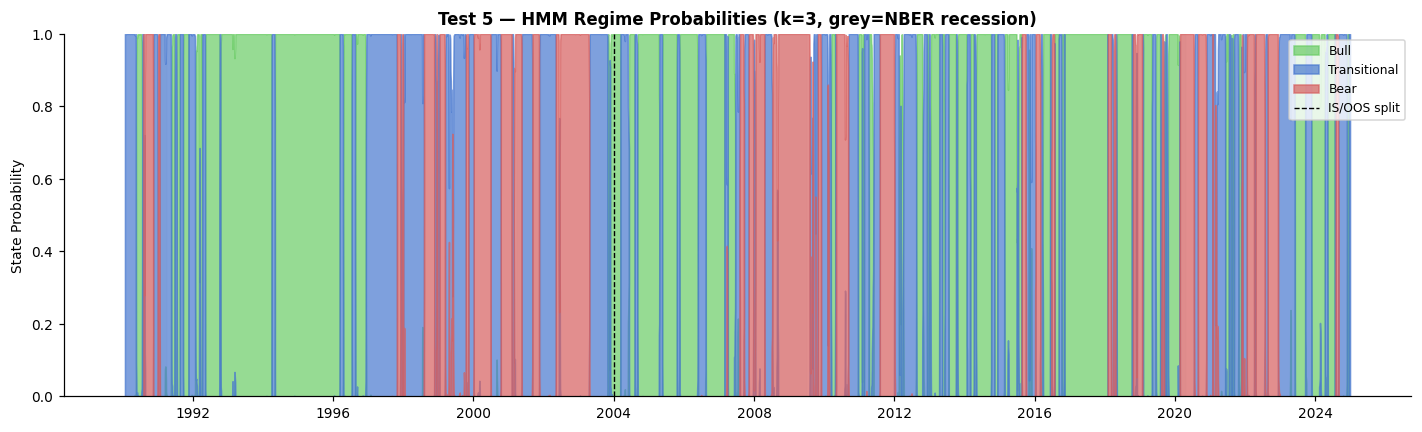

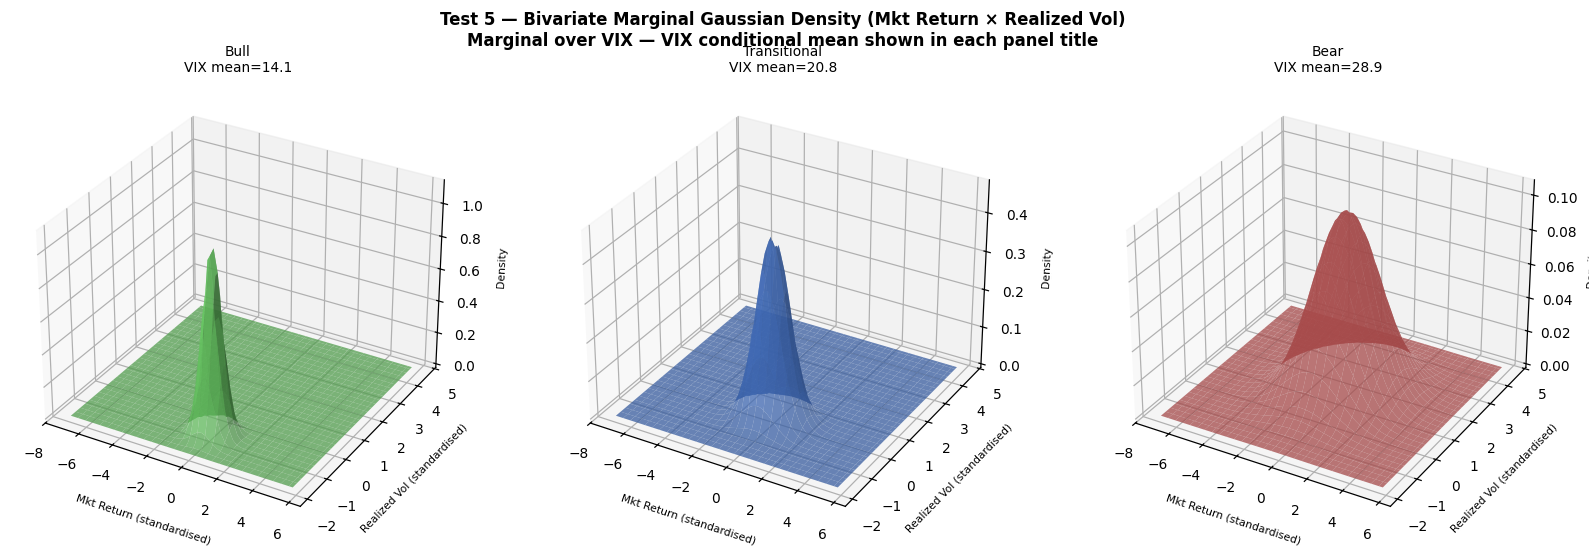

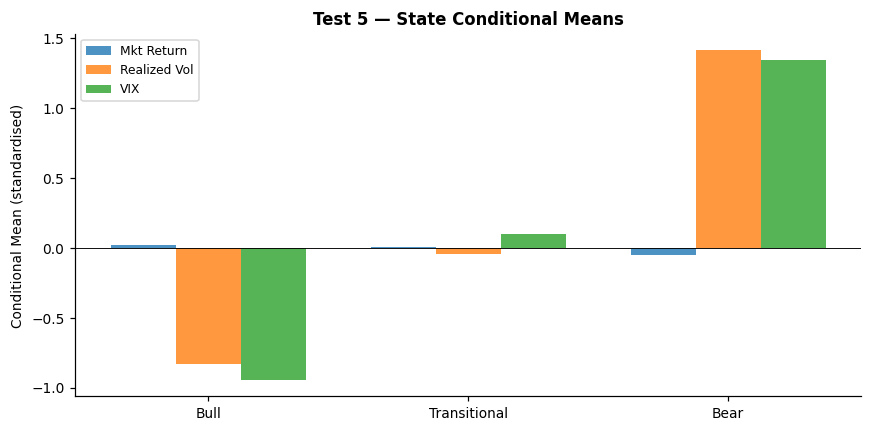

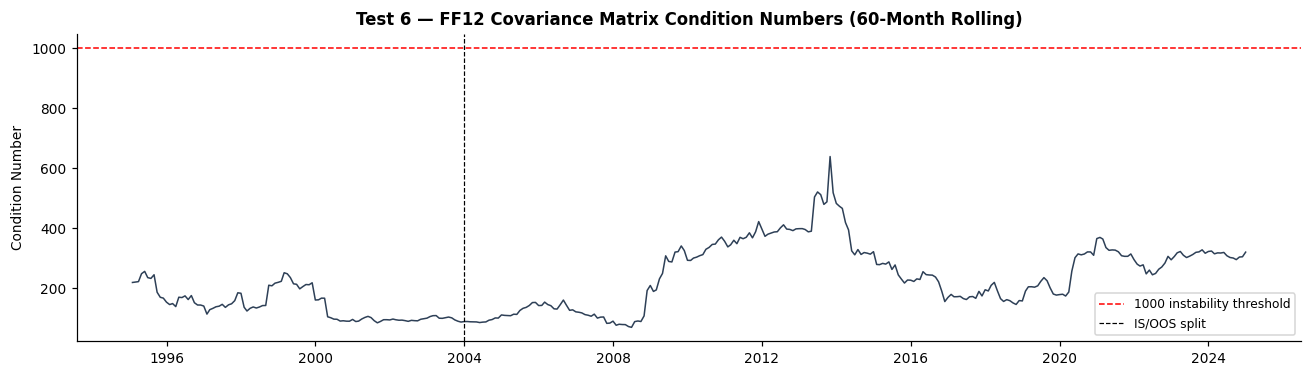

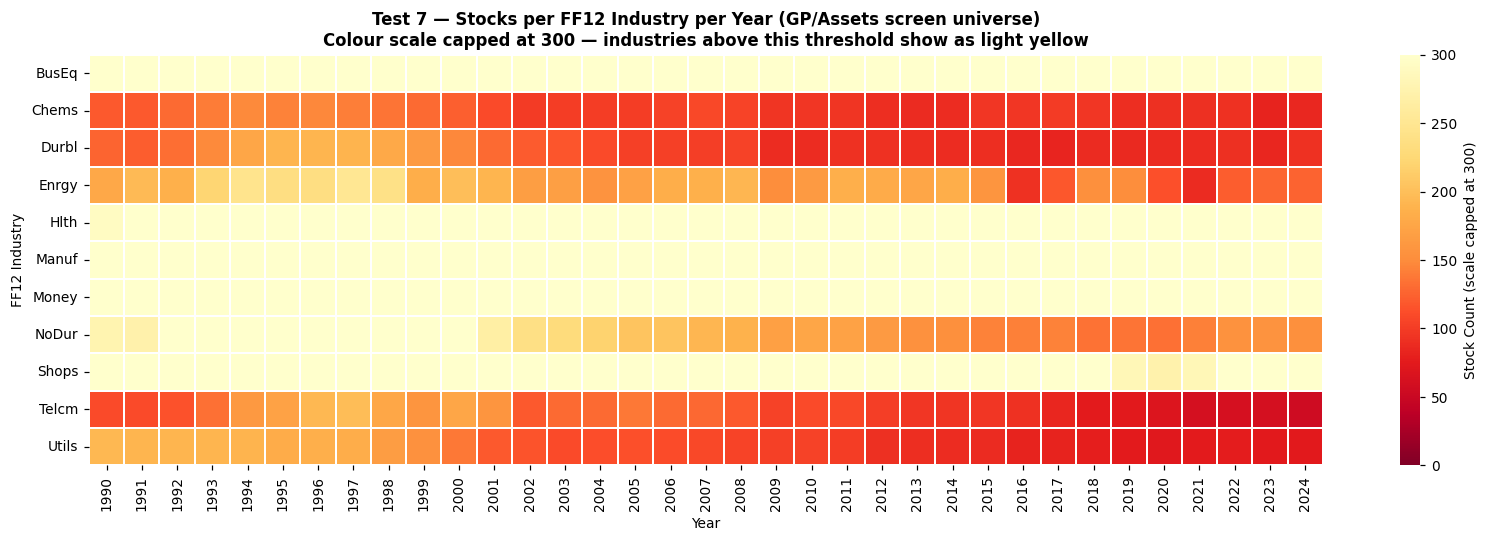

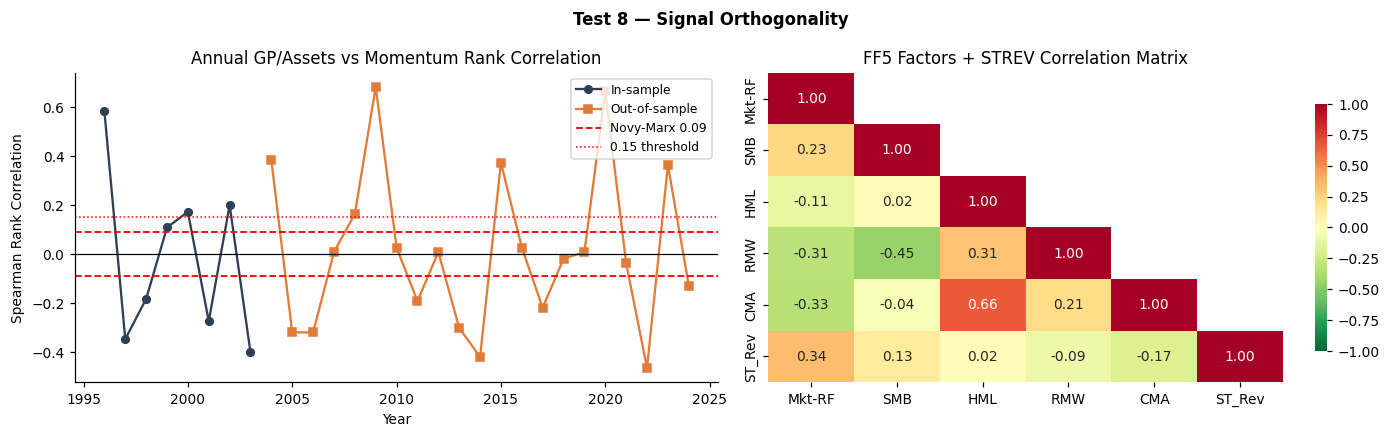


  GO / NO-GO SUMMARY — NOTEBOOK 2 DIAGNOSTIC CHECKS
  [GO]  Test 1: ADF: all daily HMM inputs stationary
         Stat : All p < 0.05: True
         Decision : GO
--------------------------------------------------------------------------------
  [GO]  Test 2: STREV residualization: mean |corr| < 0.05
         Stat : Mean |corr|=0.0323 (thresh 0.05)  |  Var reduced: 11/12 industries
         Decision : GO
--------------------------------------------------------------------------------
  [GO]  Test 3: Momentum dispersion: IS mean CS std > 0.02
         Stat : IS mean CS std (resid)=0.1186  OOS=0.1238  Raw IS=0.1394  (thresh 0.02)
         Decision : GO
--------------------------------------------------------------------------------
  [GO]  Test 4: BIC: elbow identified or k=3 theoretical
         Stat : Optimal k=3 | BIC values: {2: 68605395.8, 3: 56969774.7, 4: 49743662.0, 5: 44371458.5}
         Decision : GO
----------------------------------------------------------------------------

In [16]:
# ── Styling ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})
IS_COLOR  = "#2E4057"
OOS_COLOR = "#E07B39"
NBER_COLOR = "0.88"

def add_nber(ax, nber_df, alpha=0.25):
    """Shade NBER recession periods on an axis."""
    in_rec = False
    start  = None
    for _, row in nber_df.iterrows():
        if row["recession"] == 1 and not in_rec:
            start  = row["date"]
            in_rec = True
        elif row["recession"] == 0 and in_rec:
            ax.axvspan(start, row["date"], alpha=alpha, color=NBER_COLOR, zorder=0)
            in_rec = False
    if in_rec and start is not None:
        ax.axvspan(start, nber_df["date"].max(), alpha=alpha, color=NBER_COLOR, zorder=0)

IS_END_TS   = pd.Timestamp(IS_END)
OOS_START_TS = pd.Timestamp(OOS_START)

# ═══════════════════════════════════════════════════════════════════
# TEST 1 — ADF STATIONARITY
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
plot_cols  = ["mkt_ret","realvol","vix"]
plot_labels = ["Mkt Return (daily)","Realized Vol (daily)","VIX (daily)"]
for i, (col, label) in enumerate(zip(plot_cols, plot_labels)):
    ax = axes[i]
    add_nber(ax, nber_raw)
    ax.plot(hmm_daily["date"], hmm_daily[col], lw=0.6, color=IS_COLOR)
    ax.axvline(IS_END_TS, color="black", ls="--", lw=0.8, label="IS/OOS split")
    ax.axhspan(ax.get_ylim()[0], ax.get_ylim()[1], alpha=0)
    row = adf_df.loc[label]
    ax.set_title(f"{label}  |  ADF p-value = {row['p-value']:.4f}  |  "
                 f"{'Stationary' if row['Stationary'] else 'NON-STATIONARY'}",
                 fontsize=8)
    ax.set_ylabel(label, fontsize=7)
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("Test 1 — ADF Stationarity: HMM Input Series (Daily)", fontweight="bold")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 2 — STREV RESIDUALIZATION
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax1 = axes[0]
ind_names = list(strev_corrs.keys())
corr_vals = list(strev_corrs.values())
colors_bar = ["#E07B39" if v > 0.05 else IS_COLOR for v in corr_vals]
ax1.bar(ind_names, corr_vals, color=colors_bar)
ax1.axhline(0.05, color="red", ls="--", lw=1, label="0.05 threshold")
ax1.set_xlabel("Industry")
ax1.set_ylabel("|Correlation| with STREV")
ax1.set_title("Residualized Industry Return vs STREV Correlation")
ax1.legend(fontsize=8)
ax2 = axes[1]
raw_vars   = [var_raw[i]   for i in INDUSTRIES]
resid_vars = [var_resid[i] for i in INDUSTRIES]
ax2.scatter(raw_vars, resid_vars, color=IS_COLOR, s=40)
lim = max(max(raw_vars), max(resid_vars)) * 1.05
ax2.plot([0,lim],[0,lim], "r--", lw=1, label="45° (no change)")
for ind, rv, resv in zip(INDUSTRIES, raw_vars, resid_vars):
    ax2.annotate(ind, (rv, resv), fontsize=6, textcoords="offset points", xytext=(3,3))
ax2.set_xlabel("Raw Return Variance")
ax2.set_ylabel("Residualized Return Variance")
ax2.set_title("Variance Reduction from STREV Residualization")
ax2.legend(fontsize=8)
fig.suptitle("Test 2 — STREV Residualization Verification", fontweight="bold")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 3 — MOMENTUM DISPERSION
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 3.5))
add_nber(ax, nber_raw)
ax.plot(mom_raw["date"],   mom_raw["cs_std"],   color="lightblue", lw=1.0, label="Raw signal", alpha=0.8)
ax.plot(mom_resid["date"], mom_resid["cs_std"], color=IS_COLOR,    lw=1.2, label="Residualized signal")
ax.axvline(IS_END_TS,  color="black", ls="--", lw=0.8, label="IS/OOS split")
ax.axhline(0.02, color="red", ls="--", lw=1, label="2% go/no-go threshold")
ax.set_ylabel("Cross-sectional Std Dev")
ax.set_title("Test 3 — Momentum Signal Dispersion Across FF12 Industries", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 4 — BIC ELBOW
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bic_df["k"], bic_df["BIC"], "o-", color=IS_COLOR, lw=2, ms=7)
ax.scatter([OPTIMAL_K], bic_df.loc[bic_df["k"]==OPTIMAL_K,"BIC"].values,
           color="red", s=120, zorder=5, label=f"Optimal k={OPTIMAL_K}")
ax.set_xlabel("Number of HMM States")
ax.set_ylabel("BIC")
ax.set_title("Test 4 — BIC Elbow Plot (In-Sample Daily)", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 5A — REGIME PROBABILITY TIME SERIES (PRIMARY VISUALIZATION)
# ═══════════════════════════════════════════════════════════════════
state_colors = ["#6ACC65","#4878CF","#D65F5F","#B47CC7","#C4AD66"]
fig, ax = plt.subplots(figsize=(13, 4))
add_nber(ax, nber_raw)
for i, sl in enumerate(state_labels):
    ax.fill_between(post_df["date"], post_df[sl], alpha=0.7,
                    color=state_colors[i], label=sl)
ax.axvline(IS_END_TS, color="black", ls="--", lw=0.9, label="IS/OOS split")
ax.set_ylim(0, 1)
ax.set_ylabel("State Probability")
ax.set_title(f"Test 5 — HMM Regime Probabilities (k={OPTIMAL_K}, grey=NBER recession)",
             fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 5B — BIVARIATE MARGINAL GAUSSIAN DENSITY SURFACES
# Market return x Realized vol marginal (VIX shown in state table)
# One panel per state — this is the academically standard surface plot
# for trivariate HMM (Ang & Bekaert 2002 approach)
# ═══════════════════════════════════════════════════════════════════
# Variable indices: 0=mkt_ret, 1=realvol, 2=vix
IDX_X, IDX_Y = 0, 1
var_x_label  = "Mkt Return (standardised)"
var_y_label  = "Realized Vol (standardised)"

x_min, x_max = X_is[:, IDX_X].min() - 0.5, X_is[:, IDX_X].max() + 0.5
y_min, y_max = X_is[:, IDX_Y].min() - 0.5, X_is[:, IDX_Y].max() + 0.5
x_grid = np.linspace(x_min, x_max, 60)
y_grid = np.linspace(y_min, y_max, 60)
Xg, Yg = np.meshgrid(x_grid, y_grid)
pos    = np.dstack((Xg, Yg))

fig = plt.figure(figsize=(5 * OPTIMAL_K, 5))
for i in range(OPTIMAL_K):
    ax = fig.add_subplot(1, OPTIMAL_K, i + 1, projection="3d")
    mean_2d = means_ord[i][[IDX_X, IDX_Y]]
    cov_2d  = covars_ord[i][np.ix_([IDX_X,IDX_Y],[IDX_X,IDX_Y])]
    try:
        rv = multivariate_normal(mean_2d, cov_2d)
        Z  = rv.pdf(pos)
        ax.plot_surface(Xg, Yg, Z, alpha=0.75, color=state_colors[i],
                        edgecolor="none", rstride=2, cstride=2)
    except Exception as e:
        ax.text(0, 0, 0, f"Error: {e}", fontsize=7)
    ax.set_xlabel(var_x_label, fontsize=7, labelpad=5)
    ax.set_ylabel(var_y_label, fontsize=7, labelpad=5)
    ax.set_zlabel("Density", fontsize=7)
    ax.set_title(f"{state_labels[i]}\nVIX mean={means_ord[i][2]*is_stds['vix']+is_means['vix']:.1f}",
                 fontsize=9)
fig.suptitle(
    "Test 5 — Bivariate Marginal Gaussian Density (Mkt Return × Realized Vol)\n"
    "Marginal over VIX — VIX conditional mean shown in each panel title",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 5C — STATE CONDITIONAL STATISTICS
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(OPTIMAL_K)
w     = 0.25
for j, (col_idx, col_label) in enumerate([(0,"Mkt Return"),(1,"Realized Vol"),(2,"VIX")]):
    vals = [means_ord[i][col_idx] for i in range(OPTIMAL_K)]
    ax.bar(x_pos + j*w, vals, width=w, label=col_label, alpha=0.8)
ax.set_xticks(x_pos + w)
ax.set_xticklabels(state_labels)
ax.set_ylabel("Conditional Mean (standardised)")
ax.set_title("Test 5 — State Conditional Means", fontweight="bold")
ax.legend(fontsize=8)
ax.axhline(0, color="black", lw=0.6)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 6 — COVARIANCE CONDITION NUMBERS
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(cond_series.index, cond_series.values, color=IS_COLOR, lw=1)
ax.axhline(1000, color="red", ls="--", lw=1, label="1000 instability threshold")
ax.axvline(IS_END_TS, color="black", ls="--", lw=0.8, label="IS/OOS split")
ax.set_ylabel("Condition Number")
ax.set_title("Test 6 — FF12 Covariance Matrix Condition Numbers (60-Month Rolling)",
             fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 7 — GP/ASSETS STOCK COUNT HEATMAP
# ═══════════════════════════════════════════════════════════════════
plot_gp = gp_count_df[gp_industries].T

# Cap scale at 300: spreads the colour gradient across the range that matters.
# Industries above 300 stocks show as the same light yellow.
# Anything visibly dark red is genuinely thin (< ~75 stocks).
# Without the cap, Money (~800) and BusEq (~500) dominate the scale
# and make all other industries appear identically dark regardless of count.
SCALE_CAP = 300

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    plot_gp, ax=ax, cmap="YlOrRd_r",
    vmin=0, vmax=SCALE_CAP,
    linewidths=0.2, linecolor="white",
    cbar_kws={"label": f"Stock Count (scale capped at {SCALE_CAP})"}
)
ax.set_xlabel("Year")
ax.set_ylabel("FF12 Industry")
ax.set_title(
    f"Test 7 — Stocks per FF12 Industry per Year (GP/Assets screen universe)\n"
    f"Colour scale capped at {SCALE_CAP} — industries above this threshold show as light yellow",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# TEST 8 — ORTHOGONALITY
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax1 = axes[0]
is_sp  = spearman_df[spearman_df["is_period"]]
oos_sp = spearman_df[~spearman_df["is_period"]]
ax1.plot(is_sp["year"],  is_sp["spearman_r"],  "o-", color=IS_COLOR,  lw=1.5, ms=5, label="In-sample")
ax1.plot(oos_sp["year"], oos_sp["spearman_r"], "s-", color=OOS_COLOR, lw=1.5, ms=5, label="Out-of-sample")
ax1.axhline(0.09,  color="red",  ls="--", lw=1.2, label="Novy-Marx 0.09")
ax1.axhline(0.15,  color="red",  ls=":",  lw=1.0, label="0.15 threshold")
ax1.axhline(-0.09, color="red",  ls="--", lw=1.2)
ax1.axhline(0,     color="black",lw=0.8)
ax1.set_xlabel("Year")
ax1.set_ylabel("Spearman Rank Correlation")
ax1.set_title("Annual GP/Assets vs Momentum Rank Correlation")
ax1.legend(fontsize=8)
ax2 = axes[1]
mask = np.triu(np.ones_like(ff_corr, dtype=bool), k=1)
sns.heatmap(ff_corr, ax=ax2, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-1, vmax=1, mask=mask, cbar_kws={"shrink":0.8})
ax2.set_title("FF5 Factors + STREV Correlation Matrix")
fig.suptitle("Test 8 — Signal Orthogonality", fontweight="bold")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# GO / NO-GO SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════
SEP  = "=" * 80
SEP2 = "-" * 80

print()
print(SEP)
print("  GO / NO-GO SUMMARY — NOTEBOOK 2 DIAGNOSTIC CHECKS")
print(SEP)

tests = [
    ("Test 1", "ADF: all daily HMM inputs stationary",          t1_go, t1_stat),
    ("Test 2", "STREV residualization: mean |corr| < 0.05",     t2_go, t2_stat),
    ("Test 3", "Momentum dispersion: IS mean CS std > 0.02",    t3_go, t3_stat),
    ("Test 4", "BIC: elbow identified or k=3 theoretical",      t4_go, t4_stat),
    ("Test 5", "HMM states: min avg duration >= 40 days",       t5_go, t5_stat),
    ("Test 6", "Covariance: mean condition number < 1000",      t6_go, t6_stat),
    ("Test 7", "GP/Assets: thin industry-years (<5 stocks) < 5%", t7_go, t7_stat),
    ("Test 8", "Orthogonality: mean Spearman < 0.15",           t8_go, t8_stat),
]

for tnum, tname, go, stat in tests:
    verdict = "GO" if go else "NO-GO -- REVIEW REQUIRED"
    marker  = "[GO]" if go else "[!!]"
    print(f"  {marker}  {tnum}: {tname}")
    print(f"         Stat : {stat}")
    print(f"         Decision : {verdict}")
    print(SEP2)

all_pass = all(g for _,_,g,_ in tests)
print()
if all_pass:
    print("  ALL CHECKS PASSED — PROCEED TO NOTEBOOK 3")
else:
    n_fail = sum(1 for _,_,g,_ in tests if not g)
    print(f"  {n_fail} CHECK(S) FAILED — REVIEW BEFORE NOTEBOOK 3")
    print("  NOTE: You make the call. No check blocks execution of Notebook 3.")
print(SEP)

# ── Final state parameters table ─────────────────────────────────
print()
print(SEP)
print(f"  HMM STATE PARAMETERS (k={OPTIMAL_K}, covariance trace ordering: Bull -> Bear)")
print(SEP)
print(f"  {'State':<16} {'Mkt_Ret_mean':>14} {'RealVol_mean':>14} {'VIX_mean':>10} {'Avg_Duration':>14}")
for i, sl in enumerate(state_labels):
    mkt_m = means_ord[i][0] * is_stds["mkt_ret"] + is_means["mkt_ret"]
    vol_m = means_ord[i][1] * is_stds["realvol"] + is_means["realvol"]
    vix_m = means_ord[i][2] * is_stds["vix"]     + is_means["vix"]
    dur   = durations[sl]
    print(f"  {sl:<16} {mkt_m:>14.4f} {vol_m:>14.4f} {vix_m:>10.2f} {dur:>14.1f} days")
print(SEP)
